In [1]:
import math
import pickle as pkl
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import seaborn as sns
import torch
from emle.models import EMLE
from emle.models.interactions import Dispersion
from emle.train._utils import pad_to_max
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
data = pkl.load(
    open(
        "process_trajs/processed_traj_data.pkl",
        "rb",
    )
)

CUT_OFF = 12.0

# Get WAT data
z = pad_to_max(data["z"]).to(device=device, dtype=torch.long)
xyz_qm = pad_to_max(data["xyz_qm"]).to(device=device, dtype=dtype)
xyz_mm = pad_to_max(data["xyz_mm"]).to(device=device, dtype=dtype)
charges_mm = pad_to_max(data["charges_mm"]).to(device=device, dtype=dtype)

# Only keep MM atoms that are within 12 A of any QM atom
dists = torch.cdist(xyz_qm, xyz_mm)
mask_mm = (dists <= CUT_OFF).any(dim=1)

xyz_mm_list = []
charges_mm_list = []
for i in range(xyz_qm.shape[0]):
    xyz_mm_list.append(xyz_mm[i][mask_mm[i]])
    charges_mm_list.append(charges_mm[i][mask_mm[i]])
xyz_mm = pad_to_max(xyz_mm_list)
charges_mm = pad_to_max(charges_mm_list)

# Get CHX data
data_chx = pkl.load(
    open("../rvdw_fine_tuning_chx/process_trajs/processed_traj_data.pkl", "rb")
)

z_chx = pad_to_max(data_chx["z"]).to(device=device, dtype=torch.long)[::2]
xyz_qm_chx = pad_to_max(data_chx["xyz_qm"]).to(device=device, dtype=dtype)[::2]
xyz_mm_chx = pad_to_max(data_chx["xyz_mm"]).to(device=device, dtype=dtype)[::2]
charges_mm_chx = pad_to_max(data_chx["charges_mm"]).to(device=device, dtype=dtype)[::2]

# Only keep MM atoms that are within 12 A of any QM atom
dists_chx = torch.cdist(xyz_qm_chx, xyz_mm_chx)
mask_mm_chx = (dists_chx <= CUT_OFF).any(dim=1)

xyz_mm_chx_list = []
charges_mm_chx_list = []
for i in range(xyz_qm_chx.shape[0]):
    xyz_mm_chx_list.append(xyz_mm_chx[i][mask_mm_chx[i]])
    charges_mm_chx_list.append(charges_mm_chx[i][mask_mm_chx[i]])
xyz_mm_chx = pad_to_max(xyz_mm_chx_list)
charges_mm_chx = pad_to_max(charges_mm_chx_list)

In [4]:
def pad_two(a, b):
    """Pad tensors a and b along dim=1 to the same length."""
    import torch.nn.functional as F

    L = max(a.shape[1], b.shape[1])
    pad_a = L - a.shape[1]
    pad_b = L - b.shape[1]

    if a.dim() == 2:
        pa = F.pad(a, (0, pad_a))
    else:
        pa = F.pad(a, (0, 0, 0, pad_a))

    if b.dim() == 2:
        pb = F.pad(b, (0, pad_b))
    else:
        pb = F.pad(b, (0, 0, 0, pad_b))

    return pa, pb


z, z_chx = pad_two(z, z_chx)
xyz_qm, xyz_qm_chx = pad_two(xyz_qm, xyz_qm_chx)
xyz_mm, xyz_mm_chx = pad_two(xyz_mm, xyz_mm_chx)
charges_mm, charges_mm_chx = pad_two(charges_mm, charges_mm_chx)

In [5]:
# Cat datasets and subsample
stride = 1

z = torch.cat([z, z_chx], dim=0)[::stride]
xyz_qm = torch.cat([xyz_qm, xyz_qm_chx], dim=0)[::stride]
xyz_mm = torch.cat([xyz_mm, xyz_mm_chx], dim=0)[::stride]
charges_mm = torch.cat([charges_mm, charges_mm_chx], dim=0)[::stride]
q_mol = torch.zeros(z.shape[0], device=device, dtype=dtype)

print(f"Total number of structures: {z.shape[0]}")

Total number of structures: 2000


### Assign TIP3P and CHX LJ Parameters

In [6]:
# TIP3P LJ Parameters
# O_sigma = 3.1507 Å, O_epsilon = 0.1521 kcal/mol
# H_sigma = 1.0 Å, H_epsilon = 0.0 kcal/mol
O_sigma = 3.1507 * ANGSTROM_TO_BOHR
O_epsilon = 0.1521 * 4.184 / HARTREE_TO_KJ_MOL
H_sigma = 1.0 * ANGSTROM_TO_BOHR
H_epsilon = 0.0

sigma_mm = charges_mm.clone()
sigma_mm[charges_mm == -0.834] = O_sigma
sigma_mm[charges_mm == 0.417] = H_sigma

epsilon_mm = charges_mm.clone()
epsilon_mm[charges_mm == -0.834] = O_epsilon
epsilon_mm[charges_mm == 0.417] = H_epsilon

# OpenFF-2.0.0 LJ Parameters
# C_sigma (n16) = 3.37 Å, O_epsilon = 0.1088406109251 kcal/mol
# H_sigma (n2) = 2.64 Å, H_epsilon = 0.01577948280971 kcal/mol
C_sigma_chx = 3.37953176162662 * ANGSTROM_TO_BOHR
C_epsilon_chx = 0.1088406109251 * 4.184 / HARTREE_TO_KJ_MOL
H_sigma_chx = 2.6445434132681245 * ANGSTROM_TO_BOHR
H_epsilon_chx = 0.01577948280971 * 4.184 / HARTREE_TO_KJ_MOL

C_sigma_chx = torch.nn.Parameter(
    torch.tensor(C_sigma_chx, device=device, dtype=dtype), requires_grad=False
)
C_epsilon_chx = torch.nn.Parameter(
    torch.tensor(C_epsilon_chx, device=device, dtype=dtype), requires_grad=True
)

sigma_mm[charges_mm == -0.0764] = C_sigma_chx
sigma_mm[charges_mm == 0.0382] = H_sigma_chx

epsilon_mm[charges_mm == -0.0764] = C_epsilon_chx
epsilon_mm[charges_mm == 0.0382] = H_epsilon_chx

# Now pad adding 0s for the QM atoms
num_qm_atoms = z.shape[1]
sigma_mm = torch.cat(
    [
        torch.zeros((sigma_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        sigma_mm,
    ],
    dim=1,
)
epsilon_mm = torch.cat(
    [
        torch.zeros((epsilon_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        epsilon_mm,
    ],
    dim=1,
)

# Get idx_mm
atom_indices = (
    torch.arange(charges_mm.shape[1])
    .unsqueeze(0)
    .expand(*charges_mm.shape)
    .to(device=device, dtype=torch.long)
)


idx_mm = torch.where(charges_mm != 0.0, atom_indices + num_qm_atoms, 0)
row_ids = (
    torch.arange(idx_mm.shape[0]).unsqueeze(-1).to(device=device, dtype=torch.long)
)
row_ids = row_ids.expand(-1, idx_mm.shape[1]).unsqueeze(-1)
idx_mm = torch.cat([row_ids, idx_mm.unsqueeze(-1)], dim=-1)

# Recreate nagl_params dictionary
nagl_params = {
    "lj_sigma_mm": sigma_mm,
    "lj_eps_mm": epsilon_mm,
}

### Create EMLE model

In [7]:
model = scipy.io.loadmat(
    "../../training_scan/xdm_moments_species_1.15/ligand_patched_species_iter2_c6_1.15.mat"
)
model["sigma_scale_ref"] = np.ones_like(model["c6_ref"])
ones_file = "ligand_patched_species_iter2_c6_sigma_scales_ones_1.15.mat"
scipy.io.savemat(ones_file, model)

In [8]:
emle = EMLE(
    model=ones_file,
    device=device,
    dtype=dtype,
    alpha_mode="species",
    dispersion_mode="lj",
    nagl_params=nagl_params,
)
emle_base = emle._emle_base

### Fine-tune the Fedorov relation via Zwanzig reweighting

In [9]:
def dG(energies, beta):
    """Compute solvation free energy using Zwanzig equation."""
    return -(1 / beta) * torch.logsumexp(-beta * energies, dim=1) + (
        1 / beta
    ) * torch.log(torch.tensor(energies.shape[1], dtype=torch.float32))

In [10]:
def get_lj_parameters(c6, alpha, sigma_scale):
    """
    Calculate Lennard-Jones sigma and epsilon parameters from C6 and polarizabilities.

    Uses empirical relationships to convert C6 dispersion coefficients and
    polarizabilities into Lennard-Jones parameters.

    Parameters
    ----------

    c6: torch.Tensor (N_BATCH, N_QM_ATOMS)
        C6 dispersion coefficients.

    alpha: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Isotropic polarizabilities.

    Returns
    -------

    sigma: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones sigma parameter (distance at which potential is zero).

    epsilon: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones epsilon parameter (depth of potential well).
    """
    # Get sigma scaling factors
    radius = 2.54 * alpha ** (1 / 7.0)
    rmin = 2 * radius * sigma_scale
    sigma = rmin / (2 ** (1.0 / 6.0))
    epsilon = c6 / (2 * rmin**6.0)
    return sigma, epsilon


def get_lj_energy(
    sigma_qm,
    epsilon_qm,
    sigma_mm,
    epsilon_mm,
    mesh_data,
):
    """
    Calculate Lennard-Jones 12-6 energy between QM and MM atoms.

    Uses the standard Lennard-Jones potential:
    E_LJ = 4 * epsilon * [(sigma/r)^12 - (sigma/r)^6]

    Lorentz-Berthelot combining rules are applied to mix QM and MM parameters:
    - sigma_mix = (sigma_i + sigma_j) / 2
    - epsilon_mix = sqrt(epsilon_i * epsilon_j)

    Parameters
    ----------

    sigma_qm: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones sigma parameters for QM atoms.

    epsilon_qm: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones epsilon parameters for QM atoms.

    sigma_mm: torch.Tensor (N_BATCH, N_MM_ATOMS)
        Lennard-Jones sigma parameters for MM atoms.

    epsilon_mm: torch.Tensor (N_BATCH, N_MM_ATOMS)
        Lennard-Jones epsilon parameters for MM atoms.

    mesh_data: tuple
        Mesh data tuple (r_inv, T0, T1) from EMLEBase._get_mesh_data.

    Returns
    -------

    E_lj: torch.Tensor (N_BATCH,)
        Total Lennard-Jones energy in Hartree.
    """
    # Lorentz-Berthelot combining rules
    sigma = 0.5 * (sigma_qm[:, :, None] + sigma_mm[:, None, :])
    epsilon_product = epsilon_qm[:, :, None] * epsilon_mm[:, None, :]
    epsilon = torch.where(epsilon_product > 0, torch.sqrt(epsilon_product + 1e-16), 0.0)
    r_inv, *_ = mesh_data
    sigma_r_inv_6 = (sigma * r_inv) ** 6
    sigma_r_inv_12 = sigma_r_inv_6 * sigma_r_inv_6
    lj_energy = 4 * epsilon * (sigma_r_inv_12 - sigma_r_inv_6)

    return lj_energy.sum(dim=(1, 2))


def get_lj_energy_chunked(
    sigma_qm,
    epsilon_qm,
    sigma_mm,
    epsilon_mm,
    mesh_data,
    qm_chunk_size=32,
):
    r_inv, *_ = mesh_data
    batch_size, n_qm = sigma_qm.shape

    energy = torch.zeros(
        batch_size,
        device=sigma_qm.device,
        dtype=sigma_qm.dtype,
    )

    for start in range(0, n_qm, qm_chunk_size):
        end = min(start + qm_chunk_size, n_qm)
        sigma_mix = 0.5 * (sigma_qm[:, start:end, None] + sigma_mm[:, None, :])
        eps_prod = epsilon_qm[:, start:end, None] * epsilon_mm[:, None, :]
        epsilon_mix = torch.where(
            eps_prod > 0,
            torch.sqrt(eps_prod + 1e-16),
            0.0,
        )
        sr6 = (sigma_mix * r_inv[:, start:end, :]).pow(6)
        lj = 4 * epsilon_mix * (sr6 * sr6 - sr6)
        energy = energy + lj.sum(dim=(1, 2))

    return energy

In [11]:
# Define constants
T = 298.15
kB = 3.166811563e-6  # Hartree/K
kbT = kB * T
beta = 1.0 / kbT
NMOL = 40

In [12]:
# Calculate reference values in batches
batch_size = 512
n_configs = xyz_mm.shape[0]
total_e_lj = []
A_thole = []
c6_qm = []
s_qm = []
sigma_scale_qm = []
with torch.no_grad():
    for start in range(0, n_configs, batch_size):
        end = min(start + batch_size, n_configs)
        z_batch = z[start:end]
        charges_mm_batch = charges_mm[start:end]
        xyz_qm_batch = xyz_qm[start:end]
        xyz_mm_batch = xyz_mm[start:end]
        q_mol_batch = q_mol[start:end]

        # Zero-out elements outside batch
        idx_mm_batch = idx_mm[start:end]
        e_static, e_ind, _, _, e_lj_batch = emle.forward(
            z_batch, charges_mm_batch, xyz_qm_batch, xyz_mm_batch, idx_mm=idx_mm_batch
        )

        s, q_core, q_val, A_thole_batch, c6, _, sigma_scale = emle_base.forward(
            z_batch, xyz_qm_batch, q_mol_batch, calc_A_thole=True, calc_c6=True
        )

        A_thole.append(A_thole_batch)
        total_e_lj.append(e_lj_batch)
        c6_qm.append(c6)
        s_qm.append(s)
        sigma_scale_qm.append(sigma_scale)

e_lj = torch.cat(total_e_lj, dim=0)
A_thole = torch.cat(A_thole, dim=0)
s_qm = torch.cat(s_qm, dim=0)
sigma_scale_qm_init = torch.cat(sigma_scale_qm, dim=0)
alpha_qm = emle_base.get_isotropic_polarizabilities_thole(A_thole) * (z > 0)
c6_qm = torch.cat(c6_qm, dim=0) * alpha_qm * 0.5
dG_lj_init = dG(e_lj.view(NMOL, -1), beta)

In [13]:
# Get reference data
mols = [
    "1_4-dioxane",
    "1-propanethiol",
    "2-pentanone",
    "aceticacid",
    "acetonitrile",
    "aniline",
    "benzamide",
    "benzene",
    "ethylphenylether",
    "methanol",
    "methylbenzoate",
    "methylpentanoate",
    "m-hydroxybenzaldehyde",
    "naphthalene",
    "n-octane",
    "n-pentane",
    "o-cresol",
    "pyridine",
    "thioanisole",
    "water",
]

# Water
sign_err = [
    0.75,  # 1_4-dioxane
    1.46,  # 1-propanethiol
    0.03,  # 2-pentanone
    0.99,  # aceticacid
    -1.55,  # acetonitrile
    0.00,  # aniline
    0.42,  # benzamide
    -0.88,  # benzene
    -0.30,  # ethylphenylether
    1.10,  # methanol
    -1.49,  # methylbenzoate
    -0.53,  # methylpentanoate
    0.90,  # m-hydroxybenzaldehyde
    -0.91,  # naphthalene
    0.35,  # n-octane
    0.48,  # n-pentane
    1.59,  # o-cresol
    -0.09,  # pyridine
    0.60,  # thioanisole
    0.50,  # water
]

# Cyclohexane
sign_err += [
    2.43,  # 1_4-dioxane
    0.88,  # 1-propanethiol
    2.41,  # 2-pentanone
    1.32,  # aceticacid
    1.47,  # acetonitrile
    1.31,  # aniline
    3.65,  # benzamide
    0.64,  # benzene
    1.04,  # ethylphenylether
    1.60,  # methanol
    1.85,  # methylbenzoate
    2.54,  # methylpentanoate
    1.50,  # m-hydroxybenzaldehyde (!)
    0.40,  # naphthalene
    2.36,  # n-octane
    1.55,  # n-pentane
    2.39,  # o-cresol
    0.85,  # pyridine
    0.44,  # thioanisole
    1.32,  # water
]

# Signed errors
sign_err = torch.tensor(sign_err) * 4.184 / HARTREE_TO_KJ_MOL
# DeltaG_calc - SE = DeltaG_calc - (DeltaG_calc - DeltaG_exp) = DeltaG_exp
dG_lj_ref = dG_lj_init - sign_err.to(device=device, dtype=dtype)

In [14]:
# Get mesh data
xyz_qm_bohr = xyz_qm * ANGSTROM_TO_BOHR
xyz_mm_bohr = xyz_mm * ANGSTROM_TO_BOHR
mask = (z > 0).unsqueeze(-1)
mesh_data = emle_base._get_mesh_data(xyz_qm_bohr, xyz_mm_bohr, s_qm, mask, None)

# Get LJ parameters
lj_eps_mm = nagl_params["lj_eps_mm"].clone()
lj_eps_mm = lj_eps_mm[idx_mm[..., 0], idx_mm[..., 1]]
lj_sigma_mm = nagl_params["lj_sigma_mm"].clone()
lj_sigma_mm = lj_sigma_mm[idx_mm[..., 0], idx_mm[..., 1]]
sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm_init)


# Detach all LJ parameters since they will not be optimized
lj_eps_mm = lj_eps_mm.detach()
lj_sigma_mm = lj_sigma_mm.detach()
sigma_qm = sigma_qm.detach()
epsilon_qm = epsilon_qm.detach()

e_lj_test = get_lj_energy(sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data).view(
    NMOL, -1
)
dG_lj_test = dG(e_lj_test, beta)
print(f"Test dG_lj (kJ/mol): {dG_lj_test - dG_lj_init}")

Test dG_lj (kJ/mol): tensor([-3.7253e-09,  1.8626e-09, -7.4506e-09,  8.3819e-09, -1.8626e-09,
         5.5879e-09, -1.8626e-08, -1.8626e-09, -3.7253e-09, -1.2107e-08,
        -3.7253e-09, -1.8626e-09, -3.7253e-09, -3.7253e-09, -3.7253e-09,
        -1.8626e-09, -1.8626e-09,  3.7253e-09, -1.8626e-09, -8.8476e-09,
        -5.5879e-09, -1.8626e-09, -7.4506e-09, -7.4506e-09, -3.7253e-09,
        -7.4506e-09,  0.0000e+00, -9.3132e-09, -7.4506e-09, -2.7940e-09,
        -1.4901e-08, -3.7253e-09, -7.4506e-09, -7.4506e-09, -7.4506e-09,
        -3.7253e-09, -7.4506e-09, -1.8626e-09, -7.4506e-09, -9.3132e-10],
       device='cuda:0')


In [15]:
sigma_scale_qm = torch.nn.Parameter(
    sigma_scale_qm_init.float().clone().detach(), requires_grad=True
)
sigma_mask = sigma_scale_qm_init > 0
optimizer = torch.optim.Adam([sigma_scale_qm], lr=1e-3)
n_epochs = 100
mask = z > 0
for epoch in range(n_epochs):
    optimizer.zero_grad()
    sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm)
    sigma_qm[mask == 0] = 0.0
    epsilon_qm[mask == 0] = 0.0
    e_lj = get_lj_energy_chunked(
        sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data
    ).view(NMOL, -1)
    dG_lj = dG(e_lj, beta)
    loss = torch.mean((dG_lj_ref - dG_lj) ** 2)
    loss = loss / torch.std(dG_lj_ref)

    # Regularization to keep sigma_scale close to 1
    reg_loss = torch.mean(((sigma_scale_qm - 1.0) ** 2)[sigma_mask])
    reg_lambda = 1
    loss = loss + reg_lambda * reg_loss
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}/{n_epochs}, Loss = {loss.item():.6f}")

model_mat = scipy.io.loadmat(ones_file)
model_mat["sigma_scale_ref"] = sigma_scale_qm.detach().cpu().numpy()
scipy.io.savemat("ligand_patched_reference_iter2_c6_updated_sigma_scale.mat", model_mat)
emle._emle_base.ref_values_sigma_scale = sigma_scale_qm

Epoch 1/100, Loss = 0.000507
Epoch 2/100, Loss = 0.000492
Epoch 3/100, Loss = 0.000478
Epoch 4/100, Loss = 0.000464
Epoch 5/100, Loss = 0.000452
Epoch 6/100, Loss = 0.000441
Epoch 7/100, Loss = 0.000430
Epoch 8/100, Loss = 0.000419
Epoch 9/100, Loss = 0.000410
Epoch 10/100, Loss = 0.000400
Epoch 11/100, Loss = 0.000391
Epoch 12/100, Loss = 0.000383
Epoch 13/100, Loss = 0.000375
Epoch 14/100, Loss = 0.000367
Epoch 15/100, Loss = 0.000360
Epoch 16/100, Loss = 0.000353
Epoch 17/100, Loss = 0.000346
Epoch 18/100, Loss = 0.000340
Epoch 19/100, Loss = 0.000334
Epoch 20/100, Loss = 0.000328
Epoch 21/100, Loss = 0.000322
Epoch 22/100, Loss = 0.000316
Epoch 23/100, Loss = 0.000311
Epoch 24/100, Loss = 0.000305
Epoch 25/100, Loss = 0.000300
Epoch 26/100, Loss = 0.000296
Epoch 27/100, Loss = 0.000291
Epoch 28/100, Loss = 0.000286
Epoch 29/100, Loss = 0.000282
Epoch 30/100, Loss = 0.000278
Epoch 31/100, Loss = 0.000273
Epoch 32/100, Loss = 0.000269
Epoch 33/100, Loss = 0.000265
Epoch 34/100, Loss 

In [16]:
sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm)
sigma_qm[mask == 0] = 0.0
epsilon_qm[mask == 0] = 0.0
e_lj = get_lj_energy_chunked(
    sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data
).view(NMOL, -1)
dG_lj = dG(e_lj.view(NMOL, -1), beta)

# Plots

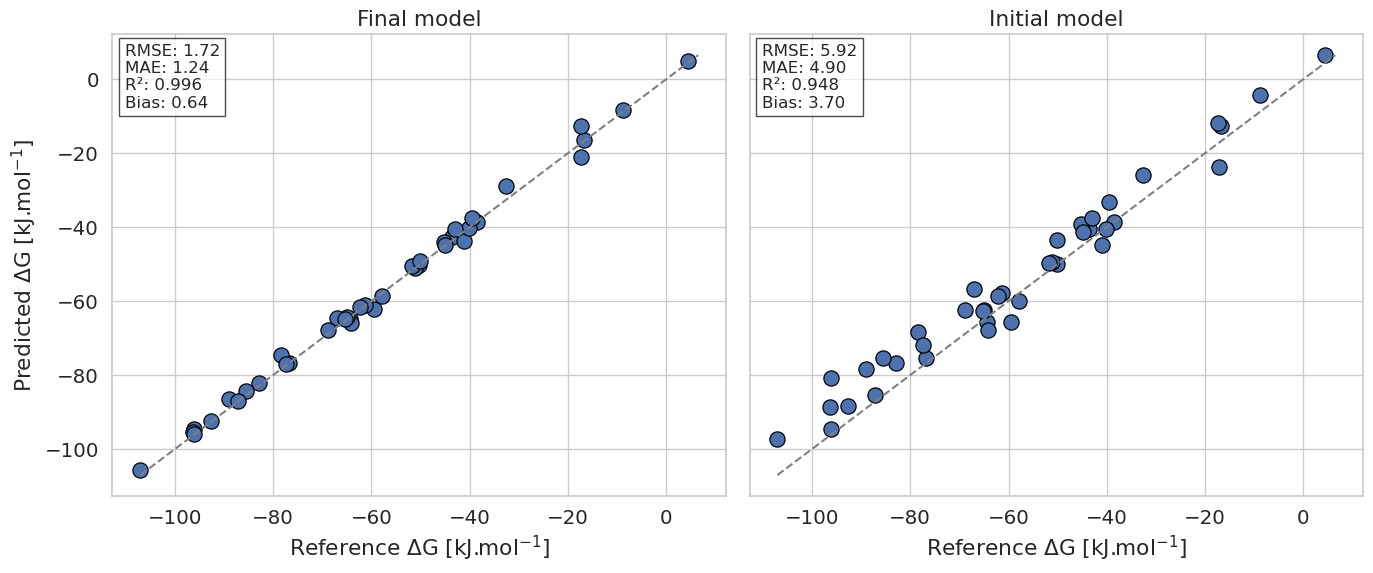

In [17]:
sns.set(style="whitegrid", font_scale=1.3)

dG_lj_calc = dG_lj.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_lj_init_local = dG_lj_init.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_ref = dG_lj_ref.detach().cpu().numpy() * HARTREE_TO_KJ_MOL

stats_calc = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_calc)),
    mean_absolute_error(dG_ref, dG_lj_calc),
    r2_score(dG_ref, dG_lj_calc),
    np.mean(dG_lj_calc - dG_ref),
)
stats_init = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_init_local)),
    mean_absolute_error(dG_ref, dG_lj_init_local),
    r2_score(dG_ref, dG_lj_init_local),
    np.mean(dG_lj_init_local - dG_ref),
)

min_v = min(dG_ref.min(), dG_lj_calc.min(), dG_lj_init_local.min())
max_v = max(dG_ref.max(), dG_lj_calc.max(), dG_lj_init_local.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Final model
ax = axes[0]
sns.scatterplot(x=dG_ref, y=dG_lj_calc, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Final model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("Predicted ΔG [kJ.mol$^{-1}$]")

rmse, mae, r2, bias = stats_calc
ax.text(
    0.02,
    0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}\nBias: {bias:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

# Initial model
ax = axes[1]
sns.scatterplot(x=dG_ref, y=dG_lj_init_local, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Initial model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("")

rmse, mae, r2, bias = stats_init
ax.text(
    0.02,
    0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}\nBias: {bias:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
)

plt.tight_layout()
plt.show()

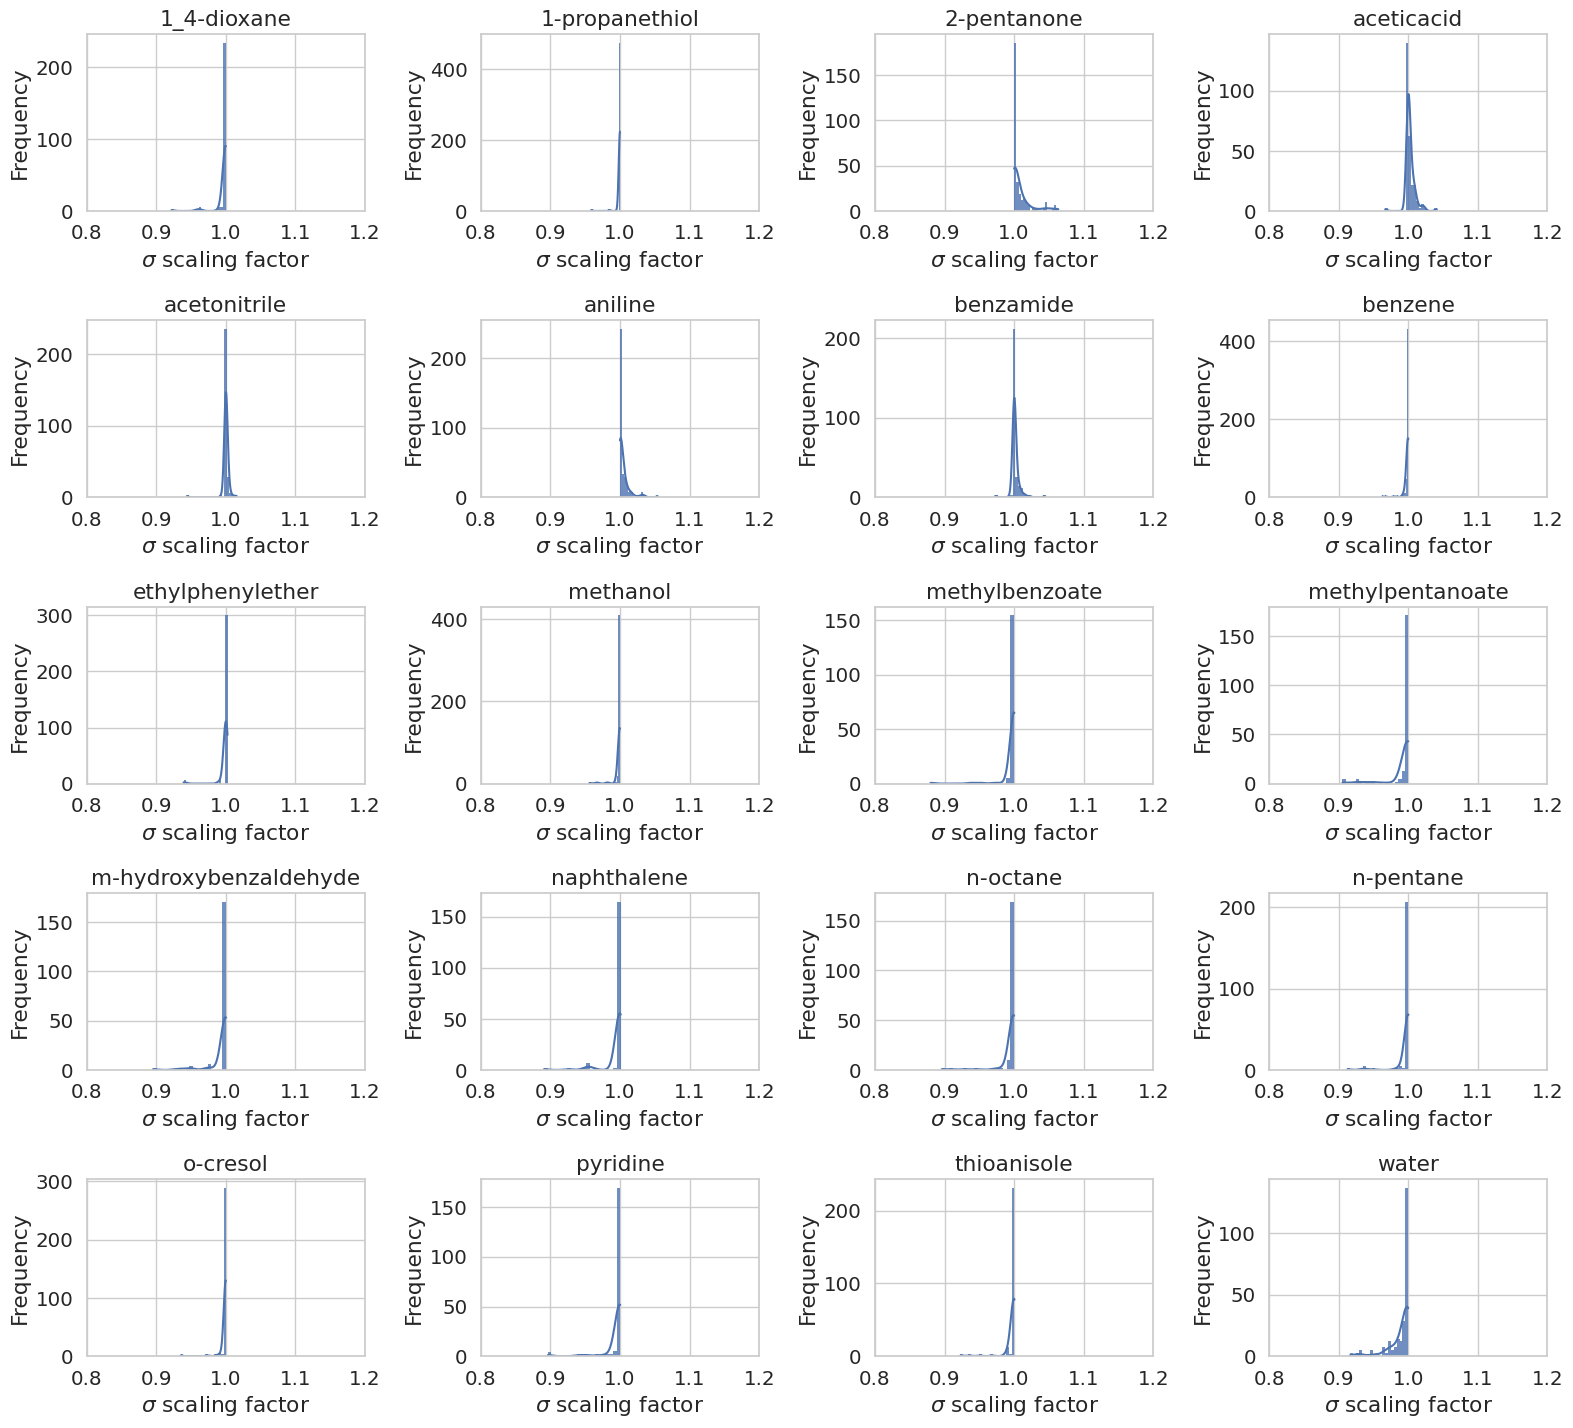

In [18]:
sigma_scale = sigma_scale_qm

chunk_size = int(sigma_scale.shape[0] / len(mols))
num_mols = len(mols)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, mol in enumerate(mols):
    ax = axes[i]
    data_block = sigma_scale[i * chunk_size : (i + 1) * chunk_size, 0]
    sns.histplot(
        data_block.detach().cpu(),
        bins=20,
        alpha=0.8,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
    )
    ax.set_title(mol)
    ax.set_xlabel(r"$\sigma$ scaling factor")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0.8, 1.2)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

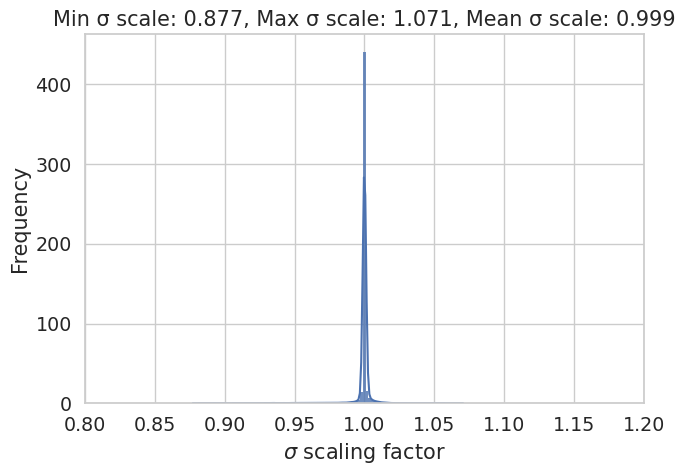

In [19]:
sns.set(style="whitegrid", font_scale=1.25)
all_sigma = sigma_scale_qm.flatten()
all_sigma = all_sigma[all_sigma > 0.0]

plt.figure(figsize=(7, 5))
sns.histplot(
    all_sigma.detach().cpu(),
    bins=100,
    alpha=0.8,
    stat="density",
    edgecolor=None,
    linewidth=0,
    kde=True,
)
plt.xlabel(r"$\sigma$ scaling factor")
plt.ylabel("Frequency")
plt.title(
    f"Min σ scale: {all_sigma.min().item():.3f}, Max σ scale: {all_sigma.max().item():.3f}, Mean σ scale: {all_sigma.mean().item():.3f}"
)
plt.xlim(0.8, 1.2)
plt.tight_layout()
plt.show()